In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity, mean_squared_error
import copy

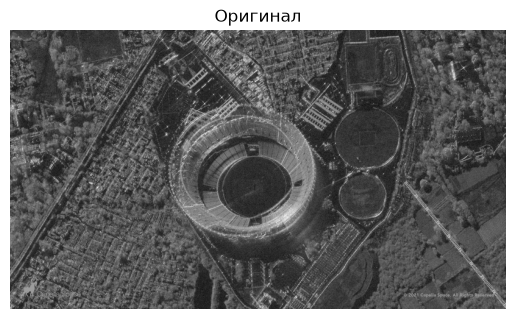

In [3]:
image = cv2.imread('sar_1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(image_gray, cmap="gray")
plt.title('Оригинал')
plt.axis('off')
plt.show()

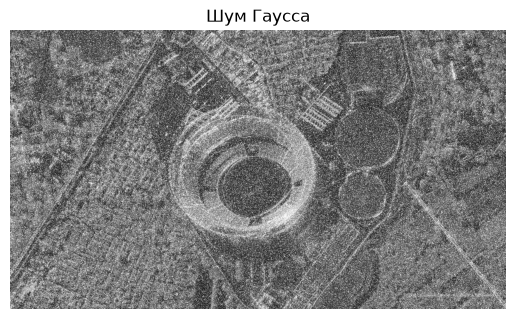

=== Шум Гаусса ===
MSE = 4230.67, SSIM = 0.1870


In [4]:
# Gaussian noise
mean = 0
stddev = 100
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)

image_noise_gauss = cv2.add(image_gray, noise_gauss)

plt.imshow(image_noise_gauss, cmap="gray")
plt.title('Шум Гаусса')
plt.axis('off')
plt.show()

mse_gauss = mean_squared_error(image_gray, image_noise_gauss)
ssim_gauss, _ = structural_similarity(image_gray, image_noise_gauss, data_range=255, full=True)

print("=== Шум Гаусса ===")
print(f"MSE = {mse_gauss:.2f}, SSIM = {ssim_gauss:.4f}")

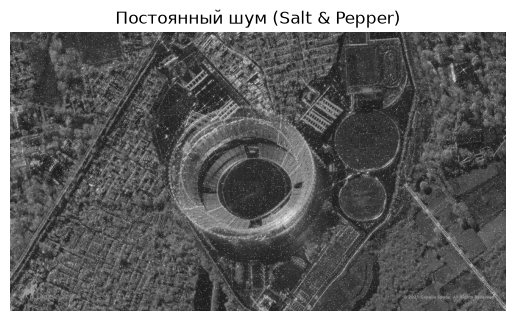

=== Постоянный шум ===
MSE = 393.96, SSIM = 0.7187


In [5]:
# Salt and pepper
noise = np.random.randint(0, 101, size=(image_gray.shape[0], image_gray.shape[1]), dtype=int)
zeros_pixel = np.where(noise == 0)
ones_pixel  = np.where(noise == 100)

image_sp = copy.deepcopy(image_gray)
image_sp[zeros_pixel] = 0
image_sp[ones_pixel]  = 255

plt.imshow(image_sp, cmap="gray")
plt.title('Постоянный шум (Salt & Pepper)')
plt.axis('off')
plt.show()

mse_sp = mean_squared_error(image_gray, image_sp)
ssim_sp, _ = structural_similarity(image_gray, image_sp, data_range=255, full=True)

print("=== Постоянный шум ===")
print(f"MSE = {mse_sp:.2f}, SSIM = {ssim_sp:.4f}")

=== Медианный фильтр (3x3) ===
Шум Гаусса:       MSE = 1038.05, SSIM = 0.4282
Salt & Pepper:    MSE = 95.68,    SSIM = 0.8163


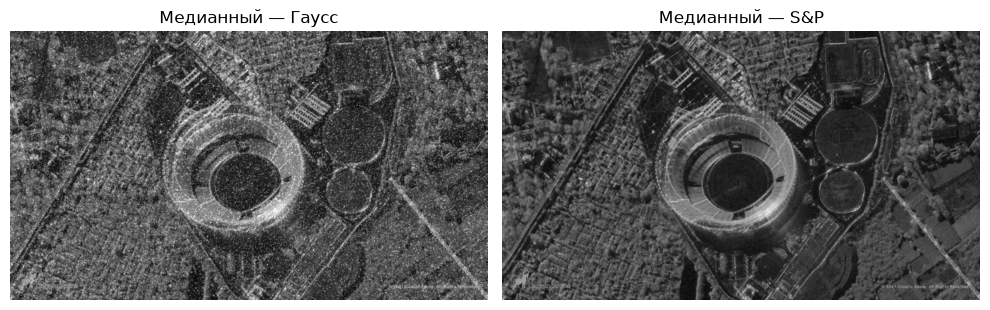

In [6]:
# Median filter
med_gauss = cv2.medianBlur(image_noise_gauss, 3)
med_sp    = cv2.medianBlur(image_sp, 3)

mse_med_gauss = mean_squared_error(image_gray, med_gauss)
ssim_med_gauss, _ = structural_similarity(image_gray, med_gauss, data_range=255, full=True)

mse_med_sp = mean_squared_error(image_gray, med_sp)
ssim_med_sp, _ = structural_similarity(image_gray, med_sp, data_range=255, full=True)

print("=== Медианный фильтр (3x3) ===")
print(f"Шум Гаусса:       MSE = {mse_med_gauss:.2f}, SSIM = {ssim_med_gauss:.4f}")
print(f"Salt & Pepper:    MSE = {mse_med_sp:.2f},    SSIM = {ssim_med_sp:.4f}")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1), plt.imshow(med_gauss, cmap="gray"), plt.title('Медианный — Гаусс'), plt.axis('off')
plt.subplot(1, 2, 2), plt.imshow(med_sp, cmap="gray"),    plt.title('Медианный — S&P'),  plt.axis('off')
plt.tight_layout()
plt.show()

=== Фильтр Гаусса (5x5) ===
Шум Гаусса:       MSE = 1764.64, SSIM = 0.4860
Salt & Pepper:    MSE = 143.11,    SSIM = 0.7344


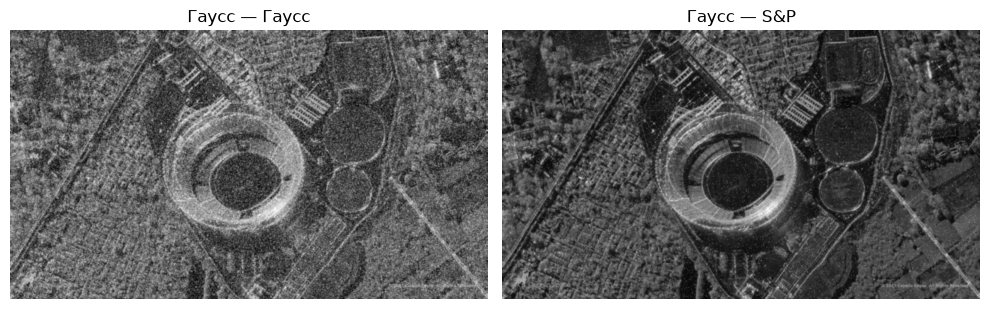

In [7]:
# Gaussian filter
gauss_gauss = cv2.GaussianBlur(image_noise_gauss, (5, 5), 0)
gauss_sp    = cv2.GaussianBlur(image_sp, (5, 5), 0)

mse_gauss_f = mean_squared_error(image_gray, gauss_gauss)
ssim_gauss_f, _ = structural_similarity(image_gray, gauss_gauss, data_range=255, full=True)

mse_gauss_sp = mean_squared_error(image_gray, gauss_sp)
ssim_gauss_sp, _ = structural_similarity(image_gray, gauss_sp, data_range=255, full=True)

print("=== Фильтр Гаусса (5x5) ===")
print(f"Шум Гаусса:       MSE = {mse_gauss_f:.2f}, SSIM = {ssim_gauss_f:.4f}")
print(f"Salt & Pepper:    MSE = {mse_gauss_sp:.2f},    SSIM = {ssim_gauss_sp:.4f}")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1), plt.imshow(gauss_gauss, cmap="gray"), plt.title('Гаусс — Гаусс'), plt.axis('off')
plt.subplot(1, 2, 2), plt.imshow(gauss_sp, cmap="gray"),    plt.title('Гаусс — S&P'),  plt.axis('off')
plt.tight_layout()
plt.show()

=== Билатеральный фильтр ===
Шум Гаусса:       MSE = 1837.55, SSIM = 0.3145
Salt & Pepper:    MSE = 268.11,    SSIM = 0.5180


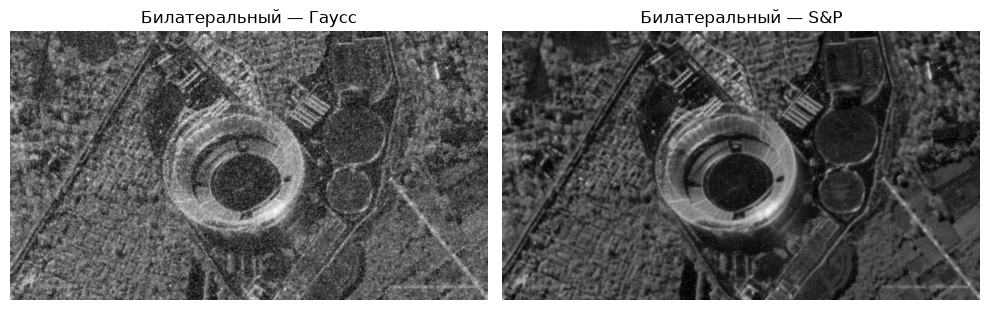

In [8]:
# Bilateral filter
bilat_gauss = cv2.bilateralFilter(image_noise_gauss, 9, 75, 75)
bilat_sp    = cv2.bilateralFilter(image_sp, 9, 75, 75)

mse_bilat_gauss = mean_squared_error(image_gray, bilat_gauss)
ssim_bilat_gauss, _ = structural_similarity(image_gray, bilat_gauss, data_range=255, full=True)

mse_bilat_sp = mean_squared_error(image_gray, bilat_sp)
ssim_bilat_sp, _ = structural_similarity(image_gray, bilat_sp, data_range=255, full=True)

print("=== Билатеральный фильтр ===")
print(f"Шум Гаусса:       MSE = {mse_bilat_gauss:.2f}, SSIM = {ssim_bilat_gauss:.4f}")
print(f"Salt & Pepper:    MSE = {mse_bilat_sp:.2f},    SSIM = {ssim_bilat_sp:.4f}")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1), plt.imshow(bilat_gauss, cmap="gray"), plt.title('Билатеральный — Гаусс'), plt.axis('off')
plt.subplot(1, 2, 2), plt.imshow(bilat_sp, cmap="gray"),    plt.title('Билатеральный — S&P'),  plt.axis('off')
plt.tight_layout()
plt.show()

=== Non-Local Means (h=20) ===
Шум Гаусса:       MSE = 4226.24, SSIM = 0.1874
Salt & Pepper:    MSE = 223.84,    SSIM = 0.5900


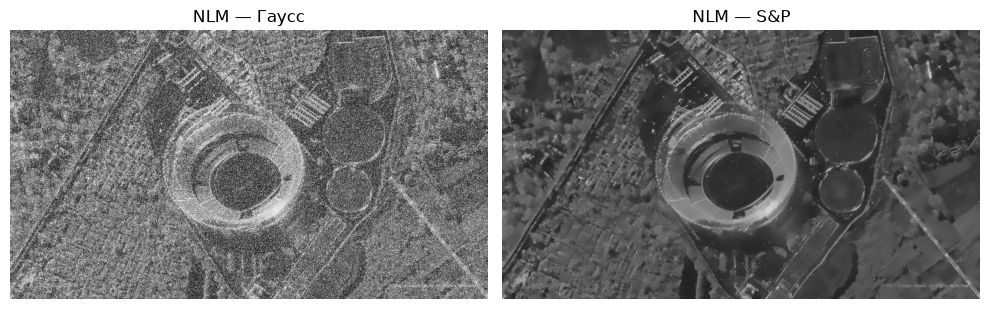

In [9]:
# Non-Local Means
nlm_gauss = cv2.fastNlMeansDenoising(image_noise_gauss, h=20)
nlm_sp    = cv2.fastNlMeansDenoising(image_sp, h=20)

mse_nlm_gauss = mean_squared_error(image_gray, nlm_gauss)
ssim_nlm_gauss, _ = structural_similarity(image_gray, nlm_gauss, data_range=255, full=True)

mse_nlm_sp = mean_squared_error(image_gray, nlm_sp)
ssim_nlm_sp, _ = structural_similarity(image_gray, nlm_sp, data_range=255, full=True)

print("=== Non-Local Means (h=20) ===")
print(f"Шум Гаусса:       MSE = {mse_nlm_gauss:.2f}, SSIM = {ssim_nlm_gauss:.4f}")
print(f"Salt & Pepper:    MSE = {mse_nlm_sp:.2f},    SSIM = {ssim_nlm_sp:.4f}")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1), plt.imshow(nlm_gauss, cmap="gray"), plt.title('NLM — Гаусс'), plt.axis('off')
plt.subplot(1, 2, 2), plt.imshow(nlm_sp, cmap="gray"),    plt.title('NLM — S&P'),  plt.axis('off')
plt.tight_layout()
plt.show()

In [10]:
# Сводная таблица
print("=" * 70)
print(f"{'Фильтр':<22}{'MSE (Гаусс)':<15}{'SSIM (Гаусс)':<15}{'MSE (S&P)':<15}{'SSIM (S&P)':<10}")
print("=" * 70)

rows = [
    ("Без фильтра",        mse_gauss,      ssim_gauss,      mse_sp,      ssim_sp),
    ("Медианный (3x3)",    mse_med_gauss,  ssim_med_gauss,  mse_med_sp,  ssim_med_sp),
    ("Гаусса (5x5)",       mse_gauss_f,    ssim_gauss_f,    mse_gauss_sp, ssim_gauss_sp),
    ("Билатеральный",      mse_bilat_gauss, ssim_bilat_gauss, mse_bilat_sp, ssim_bilat_sp),
    ("Non-Local Means",    mse_nlm_gauss,  ssim_nlm_gauss,  mse_nlm_sp,  ssim_nlm_sp),
]

for name, m1, s1, m2, s2 in rows:
    print(f"{name:<22}{m1:<15.2f}{s1:<15.4f}{m2:<15.2f}{s2:<10.4f}")

print("=" * 70)

# Лучший результат — по минимальному MSE и максимальному SSIM
best_gauss = min(rows[1:], key=lambda r: r[1])   # пропускаем «Без фильтра»
best_sp    = min(rows[1:], key=lambda r: r[3])

print("\n=== ВЫВОД ===")
print(f"Для шума Гаусса лучший фильтр:   {best_gauss[0]}  (MSE = {best_gauss[1]:.2f}, SSIM = {best_gauss[2]:.4f})")
print(f"Для Salt & Pepper лучший фильтр: {best_sp[0]}     (MSE = {best_sp[3]:.2f}, SSIM = {best_sp[4]:.4f})")

Фильтр                MSE (Гаусс)    SSIM (Гаусс)   MSE (S&P)      SSIM (S&P)
Без фильтра           4230.67        0.1870         393.96         0.7187    
Медианный (3x3)       1038.05        0.4282         95.68          0.8163    
Гаусса (5x5)          1764.64        0.4860         143.11         0.7344    
Билатеральный         1837.55        0.3145         268.11         0.5180    
Non-Local Means       4226.24        0.1874         223.84         0.5900    

=== ВЫВОД ===
Для шума Гаусса лучший фильтр:   Медианный (3x3)  (MSE = 1038.05, SSIM = 0.4282)
Для Salt & Pepper лучший фильтр: Медианный (3x3)     (MSE = 95.68, SSIM = 0.8163)
